**PROJECT NO - 5**

# TellCo Telecom User Analytics

## Project Overview

This project analyzes TellCo telecom user behavior using
xDR data.

## Objectives

- User Overview Analysis
- User Engagement Analysis
- User Experience Analysis
- User Satisfaction Analysis

## Technologies

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- MySQL
- GitHub Actions

## Machine Learning

The project uses:

- K-Means clustering
- PCA
- Regression models

## Best Current Regression Model

Hist Gradient Boosting

## Dashboard

The project includes a Streamlit dashboard for:

- User Overview
- Engagement
- Experience
- Satisfaction
- Model Results

## Submitted By

Rashika Singh

**Import Libraries**

In [79]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")

Libraries imported successfully


**Load Your Dataset**

In [80]:
df = pd.read_csv("tellco.csv")

**Display First 5 Records**

In [81]:
df.head()

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,1.311450e+19,4/4/19 12:01,770.0,4/25/19 14:35,662.0,1823652.0,2.082014e+14,3.366496e+10,3.552121e+13,9.16457E+15,...,15854611.0,2501332.0,8198936.0,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0
1,1.311450e+19,4/9/19 13:04,235.0,4/25/19 8:15,606.0,1365104.0,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,...,20247395.0,19111729.0,18338413.0,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0
2,1.311450e+19,4/9/19 17:42,1.0,4/25/19 11:58,652.0,1361762.0,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,...,19725661.0,14699576.0,17587794.0,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0
3,1.311450e+19,4/10/19 0:31,486.0,4/25/19 7:36,171.0,1321509.0,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,...,21388122.0,15146643.0,13994646.0,1097942.0,799538153.0,10849722.0,749039933.0,12797283.0,43324218.0,846028530.0
4,1.311450e+19,4/12/19 20:10,565.0,4/25/19 10:40,954.0,1089009.0,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,...,15259380.0,18962873.0,17124581.0,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0


**Display Last 5 Records**

In [82]:
df.tail()

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
149996,7.277830e+18,4/29/19 7:28,451.0,4/30/19 6:02,214.0,81230.0,2.082022e+14,3.365069e+10,3.548311e+13,D20434A,...,16191667.0,11763428.00,17883703.00,19678161.00,526609673.0,9.197207e+06,3264510.0,1.348742e+07,57628851.0,574175259.0
149997,7.349880e+18,4/29/19 7:28,483.0,4/30/19 10:41,187.0,97970.0,2.082019e+14,3.366345e+10,3.566051e+13,D10223C,...,13877234.0,8288284.00,19350146.00,21293148.00,626893062.0,4.735033e+06,712180387.0,2.457758e+06,39135081.0,666648844.0
149998,1.311450e+19,4/29/19 7:28,283.0,4/30/19 10:46,810.0,98249.0,2.082017e+14,3.362189e+10,3.572121e+13,T51102A,...,22660510.0,1855903.00,9963942.00,5065760.00,553539484.0,1.339432e+07,121100856.0,1.131473e+07,34912224.0,592786405.0
149999,1.311450e+19,4/29/19 7:28,696.0,4/30/19 10:40,327.0,97910.0,2.082021e+14,3.361962e+10,8.618620e+13,L88342B,...,8817106.0,8305402.00,3322253.00,13172589.00,352536971.0,2.529475e+06,814713113.0,1.406930e+06,29626096.0,371895920.0
150000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11634072.5,11009410.13,11626851.72,11001754.82,422044702.6,8.288398e+06,421100544.2,8.264799e+06,NaN,NaN


**Number of Rows and Columns**

In [83]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 150001
Columns: 55


In [84]:
df.shape

(150001, 55)

**Dataset Information**

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150001 entries, 0 to 150000
Data columns (total 55 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   Bearer Id                                 149010 non-null  float64
 1   Start                                     150000 non-null  object 
 2   Start ms                                  150000 non-null  float64
 3   End                                       150000 non-null  object 
 4   End ms                                    150000 non-null  float64
 5   Dur. (ms)                                 150000 non-null  float64
 6   IMSI                                      149431 non-null  float64
 7   MSISDN/Number                             148935 non-null  float64
 8   IMEI                                      149429 non-null  float64
 9   Last Location Name                        148848 non-null  object 
 10  Avg RTT DL (ms)     

**Data Types**

In [86]:
df.dtypes

,0
Bearer Id,float64
Start,object
Start ms,float64
End,object
End ms,float64
Dur. (ms),float64
IMSI,float64
MSISDN/Number,float64
IMEI,float64
Last Location Name,object


In [87]:
data_types = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values
})

data_types

,Column,Data_Type
0,Bearer Id,float64
1,Start,object
2,Start ms,float64
3,End,object
4,End ms,float64
5,Dur. (ms),float64
6,IMSI,float64
7,MSISDN/Number,float64
8,IMEI,float64
9,Last Location Name,object


**Basic Statistical Analysis**

In [88]:
df.describe()

,Bearer Id,Start ms,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Avg RTT DL (ms),Avg RTT UL (ms),Avg Bearer TP DL (kbps),...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
count,1.490100e+05,150000.000000,150000.000000,1.500000e+05,1.494310e+05,1.489350e+05,1.494290e+05,122172.000000,122189.000000,150000.000000,...,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500000e+05,1.500000e+05
mean,1.013887e+19,499.188200,498.800880,1.046086e+05,2.082016e+14,4.188282e+10,4.847455e+13,109.795706,17.662883,13300.045927,...,1.163407e+07,1.100941e+07,1.162685e+07,1.100175e+07,4.220447e+08,8.288398e+06,4.211005e+08,8.264799e+06,4.112121e+07,4.546434e+08
std,2.893170e+18,288.611834,288.097653,8.103762e+04,2.148809e+10,2.447443e+12,2.241637e+13,619.782739,84.793524,23971.878541,...,6.710569e+06,6.345423e+06,6.725218e+06,6.359490e+06,2.439675e+08,4.782700e+06,2.432050e+08,4.769004e+06,1.127639e+07,2.441429e+08
min,6.917540e+18,0.000000,0.000000,7.142000e+03,2.040471e+14,3.360100e+10,4.400152e+11,0.000000,0.000000,0.000000,...,5.300000e+01,1.050000e+02,4.200000e+01,3.500000e+01,2.516000e+03,5.900000e+01,3.290000e+03,1.480000e+02,2.866892e+06,7.114041e+06
25%,7.349880e+18,250.000000,251.000000,5.744050e+04,2.082014e+14,3.365130e+10,3.546071e+13,32.000000,2.000000,43.000000,...,5.833501e+06,5.517965e+06,5.777156e+06,5.475981e+06,2.104733e+08,4.128476e+06,2.101869e+08,4.145943e+06,3.322201e+07,2.431068e+08
50%,7.349880e+18,499.000000,500.000000,8.639900e+04,2.082015e+14,3.366371e+10,3.572201e+13,45.000000,5.000000,63.000000,...,1.161602e+07,1.101345e+07,1.164222e+07,1.099638e+07,4.234081e+08,8.291208e+06,4.218030e+08,8.267071e+06,4.114331e+07,4.558411e+08
75%,1.304240e+19,749.000000,750.000000,1.324302e+05,2.082018e+14,3.368349e+10,8.611970e+13,70.000000,15.000000,19710.750000,...,1.744852e+07,1.651556e+07,1.747048e+07,1.650727e+07,6.331742e+08,1.243162e+07,6.316918e+08,1.238415e+07,4.903424e+07,6.657055e+08
max,1.318650e+19,999.000000,999.000000,1.859336e+06,2.140743e+14,8.823971e+14,9.900120e+13,96923.000000,7120.000000,378160.000000,...,2.325910e+07,2.201196e+07,2.325919e+07,2.201196e+07,8.434419e+08,1.655879e+07,8.434425e+08,1.655882e+07,7.833131e+07,9.029696e+08


**For all columns including categorical:**

In [89]:
df.describe(include="all")

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
count,1.490100e+05,150000,150000.000000,150000,150000.000000,1.500000e+05,1.494310e+05,1.489350e+05,1.494290e+05,148848,...,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500000e+05,1.500000e+05
unique,NaN,9997,NaN,6403,NaN,NaN,NaN,NaN,NaN,45036,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,4/26/19 7:25,NaN,4/25/19 0:01,NaN,NaN,NaN,NaN,NaN,9.16457E+15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,203,NaN,1150,NaN,NaN,NaN,NaN,NaN,1881,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.013887e+19,NaN,499.188200,NaN,498.800880,1.046086e+05,2.082016e+14,4.188282e+10,4.847455e+13,NaN,...,1.163407e+07,1.100941e+07,1.162685e+07,1.100175e+07,4.220447e+08,8.288398e+06,4.211005e+08,8.264799e+06,4.112121e+07,4.546434e+08
std,2.893170e+18,NaN,288.611834,NaN,288.097653,8.103762e+04,2.148809e+10,2.447443e+12,2.241637e+13,NaN,...,6.710569e+06,6.345423e+06,6.725218e+06,6.359490e+06,2.439675e+08,4.782700e+06,2.432050e+08,4.769004e+06,1.127639e+07,2.441429e+08
min,6.917540e+18,NaN,0.000000,NaN,0.000000,7.142000e+03,2.040471e+14,3.360100e+10,4.400152e+11,NaN,...,5.300000e+01,1.050000e+02,4.200000e+01,3.500000e+01,2.516000e+03,5.900000e+01,3.290000e+03,1.480000e+02,2.866892e+06,7.114041e+06
25%,7.349880e+18,NaN,250.000000,NaN,251.000000,5.744050e+04,2.082014e+14,3.365130e+10,3.546071e+13,NaN,...,5.833501e+06,5.517965e+06,5.777156e+06,5.475981e+06,2.104733e+08,4.128476e+06,2.101869e+08,4.145943e+06,3.322201e+07,2.431068e+08
50%,7.349880e+18,NaN,499.000000,NaN,500.000000,8.639900e+04,2.082015e+14,3.366371e+10,3.572201e+13,NaN,...,1.161602e+07,1.101345e+07,1.164222e+07,1.099638e+07,4.234081e+08,8.291208e+06,4.218030e+08,8.267071e+06,4.114331e+07,4.558411e+08
75%,1.304240e+19,NaN,749.000000,NaN,750.000000,1.324302e+05,2.082018e+14,3.368349e+10,8.611970e+13,NaN,...,1.744852e+07,1.651556e+07,1.747048e+07,1.650727e+07,6.331742e+08,1.243162e+07,6.316918e+08,1.238415e+07,4.903424e+07,6.657055e+08


**Note: For the project, mean, median and dispersion are particularly important because the PDF asks for non-graphical univariate analysis**

**Missing Value Count and Missing percentage:**

In [90]:
missing_report = pd.DataFrame({
    "Column": df.columns,
    "Missing_Count": df.isnull().sum().values,
    "Missing_Percentage": (
        df.isnull().mean().values * 100
    )
})

missing_report = missing_report.sort_values(
    "Missing_Count",
    ascending=False
)

missing_report

,Column,Missing_Count,Missing_Percentage
34,Nb of sec with 37500B < Vol UL,130254,86.835421
36,Nb of sec with 6250B < Vol UL < 37500B,111843,74.561503
31,Nb of sec with 125000B < Vol DL,97538,65.024900
15,TCP UL Retrans. Vol (Bytes),96649,64.432237
33,Nb of sec with 31250B < Vol DL < 125000B,93586,62.390251
32,Nb of sec with 1250B < Vol UL < 6250B,92894,61.928920
35,Nb of sec with 6250B < Vol DL < 31250B,88317,58.877607
14,TCP DL Retrans. Vol (Bytes),88146,58.763608
25,HTTP UL (Bytes),81810,54.539636
24,HTTP DL (Bytes),81474,54.315638


**Check Duplicate Records**

In [91]:
duplicate_count = df.duplicated().sum()

print("Duplicate records:", duplicate_count)

Duplicate records: 0


**Duplicate percentage:**

In [92]:
duplicate_percentage = (
    df.duplicated().mean() * 100
)

print(
    "Duplicate percentage:",
    duplicate_percentage
)

Duplicate percentage: 0.0


**Remove Duplicate Records**

In [93]:
df_clean = df.copy()

In [94]:
df_clean = df_clean.drop_duplicates()
print(
    "Duplicates after cleaning:",
    df_clean.duplicated().sum()
)

Duplicates after cleaning: 0


**Identify Numeric Columns**

In [95]:
numeric_columns = df_clean.select_dtypes(
    include=np.number
).columns.tolist()

numeric_columns

['Bearer Id',
 'Start ms',
 'End ms',
 'Dur. (ms)',
 'IMSI',
 'MSISDN/Number',
 'IMEI',
 'Avg RTT DL (ms)',
 'Avg RTT UL (ms)',
 'Avg Bearer TP DL (kbps)',
 'Avg Bearer TP UL (kbps)',
 'TCP DL Retrans. Vol (Bytes)',
 'TCP UL Retrans. Vol (Bytes)',
 'DL TP < 50 Kbps (%)',
 '50 Kbps < DL TP < 250 Kbps (%)',
 '250 Kbps < DL TP < 1 Mbps (%)',
 'DL TP > 1 Mbps (%)',
 'UL TP < 10 Kbps (%)',
 '10 Kbps < UL TP < 50 Kbps (%)',
 '50 Kbps < UL TP < 300 Kbps (%)',
 'UL TP > 300 Kbps (%)',
 'HTTP DL (Bytes)',
 'HTTP UL (Bytes)',
 'Activity Duration DL (ms)',
 'Activity Duration UL (ms)',
 'Dur. (ms).1',
 'Nb of sec with 125000B < Vol DL',
 'Nb of sec with 1250B < Vol UL < 6250B',
 'Nb of sec with 31250B < Vol DL < 125000B',
 'Nb of sec with 37500B < Vol UL',
 'Nb of sec with 6250B < Vol DL < 31250B',
 'Nb of sec with 6250B < Vol UL < 37500B',
 'Nb of sec with Vol DL < 6250B',
 'Nb of sec with Vol UL < 1250B',
 'Social Media DL (Bytes)',
 'Social Media UL (Bytes)',
 'Google DL (Bytes)',
 'Google UL 

**Identify Categorical Columns**

In [96]:
categorical_columns = df_clean.select_dtypes(
    exclude=np.number
).columns.tolist()

categorical_columns

['Start', 'End', 'Last Location Name', 'Handset Manufacturer', 'Handset Type']

**Missing Value Treatment**

**Numeric columns**

In [97]:
for col in numeric_columns:

    if df_clean[col].isnull().sum() > 0:

        mean_value = df_clean[col].mean()

        df_clean[col] = df_clean[col].fillna(
            mean_value
        )

**Categorical columns**

In [98]:
for col in categorical_columns:

    if df_clean[col].isnull().sum() > 0:

        mode_value = df_clean[col].mode()[0]

        df_clean[col] = df_clean[col].fillna(
            mode_value
        )

In [99]:
df_clean.isnull().sum().sum()

np.int64(0)

**Outlier Detection Using IQR**

In [100]:
outlier_report = []

for col in numeric_columns:

    Q1 = df_clean[col].quantile(0.25)

    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR

    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    )

    count = outliers.sum()

    percentage = (
        count / len(df_clean) * 100
    )

    outlier_report.append([
        col,
        Q1,
        Q3,
        IQR,
        lower_bound,
        upper_bound,
        count,
        percentage
    ])

**Create table:**

In [101]:
outlier_df = pd.DataFrame(
    outlier_report,
    columns=[
        "Variable",
        "Q1",
        "Q3",
        "IQR",
        "Lower_Bound",
        "Upper_Bound",
        "Outlier_Count",
        "Outlier_Percentage"
    ]
)

outlier_df

,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,Bearer Id,7.349880e+18,1.304240e+19,5.692520e+18,-1.188900e+18,2.158118e+19,0,0.000000
1,Start ms,2.500000e+02,7.490000e+02,4.990000e+02,-4.985000e+02,1.497500e+03,0,0.000000
2,End ms,2.510000e+02,7.500000e+02,4.990000e+02,-4.975000e+02,1.498500e+03,0,0.000000
3,Dur. (ms),5.744200e+04,1.324300e+05,7.498800e+04,-5.504000e+04,2.449120e+05,7184,4.789301
4,IMSI,2.082014e+14,2.082018e+14,3.703424e+08,2.082008e+14,2.082023e+14,13250,8.833274
5,MSISDN/Number,3.365151e+10,3.368473e+10,3.322217e+07,3.360168e+10,3.373456e+10,24742,16.494557
6,IMEI,3.546261e+13,8.611970e+13,5.065709e+13,-4.052303e+13,1.621053e+14,0,0.000000
7,Avg RTT DL (ms),3.500000e+01,1.097957e+02,7.479571e+01,-7.719356e+01,2.219893e+02,7718,5.145299
8,Avg RTT UL (ms),3.000000e+00,1.766288e+01,1.466288e+01,-1.899432e+01,3.965721e+01,8975,5.983293
9,Avg Bearer TP DL (kbps),4.300000e+01,1.971000e+04,1.966700e+04,-2.945750e+04,4.921050e+04,13235,8.823275


**outliers should be replaced with the corresponding variable mean.**

**Outlier Treatment**

In [102]:
for col in numeric_columns:

    Q1 = df_clean[col].quantile(0.25)

    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR

    upper_bound = Q3 + 1.5 * IQR

    mean_value = df_clean[col].mean()

    mask = (
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    )

    df_clean.loc[mask, col] = mean_value

**Check Clean Dataset**

In [103]:
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

print(
    "Missing values:",
    df_clean.isnull().sum().sum()
)

print(
    "Duplicates:",
    df_clean.duplicated().sum()
)

Rows: 150001
Columns: 55
Missing values: 0
Duplicates: 0


**Univariate Analysis**

In [104]:
univariate = pd.DataFrame()

for col in numeric_columns:

    s = df_clean[col]

    univariate.loc[col, "Mean"] = s.mean()
    univariate.loc[col, "Median"] = s.median()
    univariate.loc[col, "Std_Dev"] = s.std()
    univariate.loc[col, "Variance"] = s.var()
    univariate.loc[col, "Minimum"] = s.min()
    univariate.loc[col, "Maximum"] = s.max()
    univariate.loc[col, "Skewness"] = s.skew()
    univariate.loc[col, "Kurtosis"] = s.kurtosis()

univariate

,Mean,Median,Std_Dev,Variance,Minimum,Maximum,Skewness,Kurtosis
Bearer Id,1.013887e+19,7.349880e+18,2.883597e+18,8.315130e+36,6.917540e+18,1.318650e+19,0.026755,-1.988473
Start ms,4.991882e+02,4.990000e+02,2.886109e+02,8.329624e+04,0.000000e+00,9.990000e+02,0.000968,-1.197441
End ms,4.988009e+02,5.000000e+02,2.880967e+02,8.299970e+04,0.000000e+00,9.990000e+02,-0.001163,-1.199123
Dur. (ms),9.285257e+04,8.639900e+04,4.934896e+04,2.435320e+09,7.142000e+03,2.449000e+05,0.582372,0.110966
IMSI,2.082016e+14,2.082016e+14,3.310759e+08,1.096113e+17,2.082009e+14,2.082022e+14,-0.610410,-0.298161
MSISDN/Number,3.501433e+10,3.366386e+10,3.052711e+09,9.319047e+18,3.360171e+10,4.188282e+10,1.805415,1.259876
IMEI,4.847455e+13,3.572241e+13,2.237359e+13,5.005776e+26,4.400152e+11,9.900120e+13,1.073519,-0.703064
Avg RTT DL (ms),6.708933e+01,5.400000e+01,3.912316e+01,1.530621e+03,0.000000e+00,2.210000e+02,0.845648,0.312710
Avg RTT UL (ms),1.072181e+01,7.000000e+00,8.741881e+00,7.642048e+01,0.000000e+00,3.900000e+01,0.772851,-0.045618
Avg Bearer TP DL (kbps),7.943877e+03,6.300000e+01,1.256140e+04,1.577888e+08,0.000000e+00,4.920500e+04,1.594770,1.525199


**`Histogram: For session duration `**

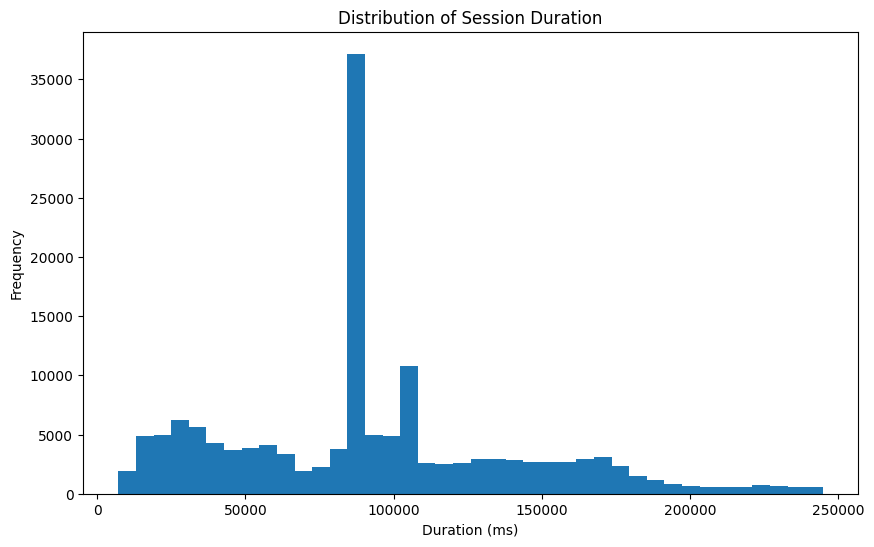

In [105]:
plt.figure(figsize=(10,6))

plt.hist(
    df_clean["Dur. (ms)"],
    bins=40
)

plt.title("Distribution of Session Duration")

plt.xlabel("Duration (ms)")

plt.ylabel("Frequency")

plt.show()

**Boxplot**

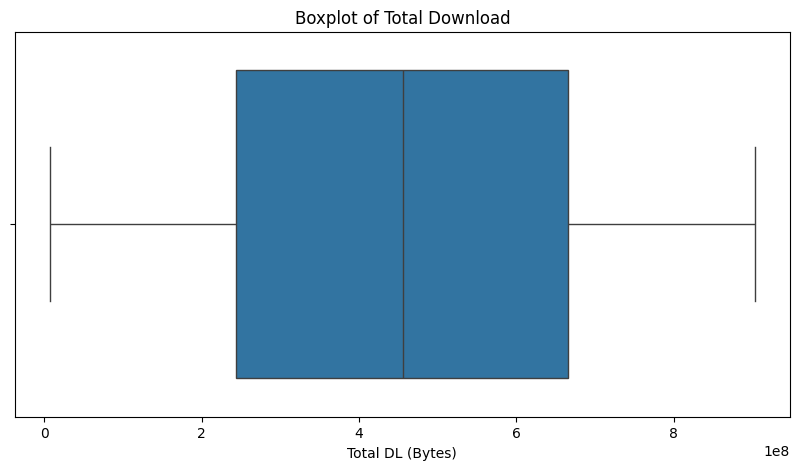

In [106]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df_clean["Total DL (Bytes)"]
)

plt.title("Boxplot of Total Download")

plt.show()

**For all important numeric variables:**

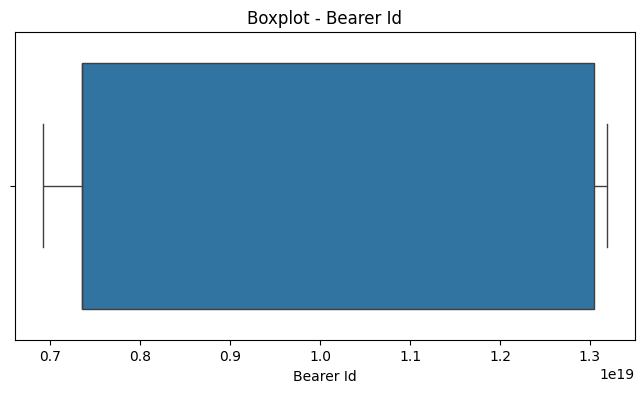

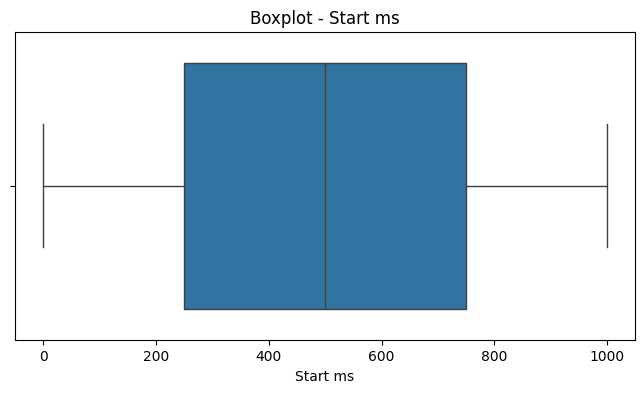

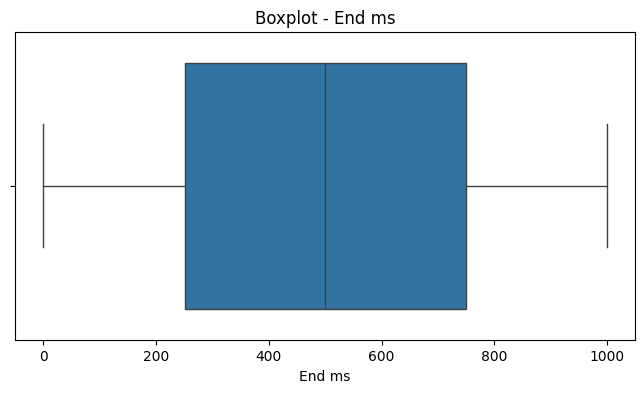

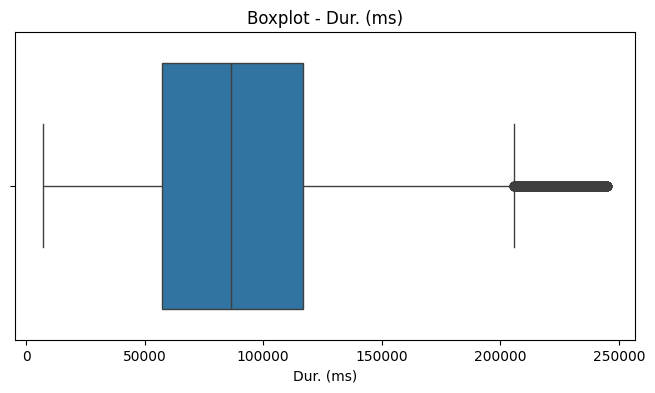

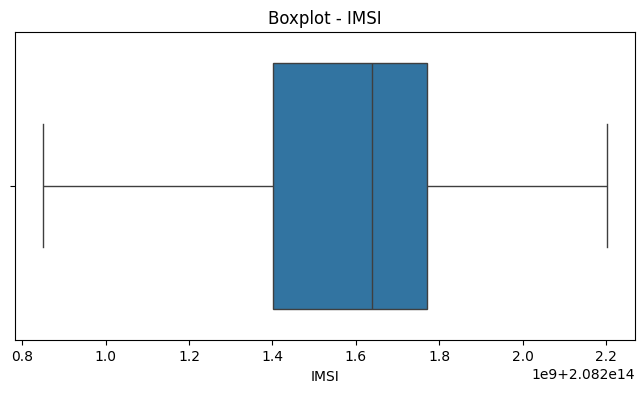

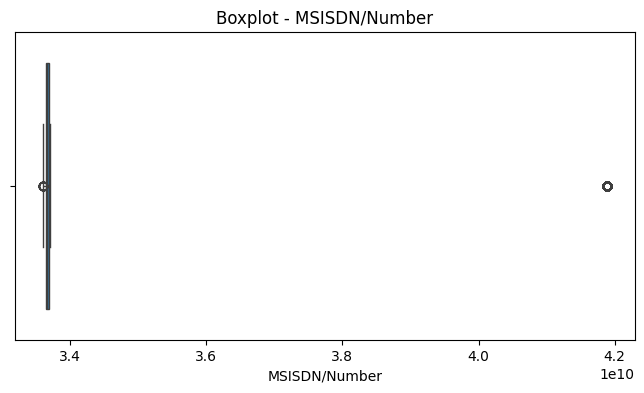

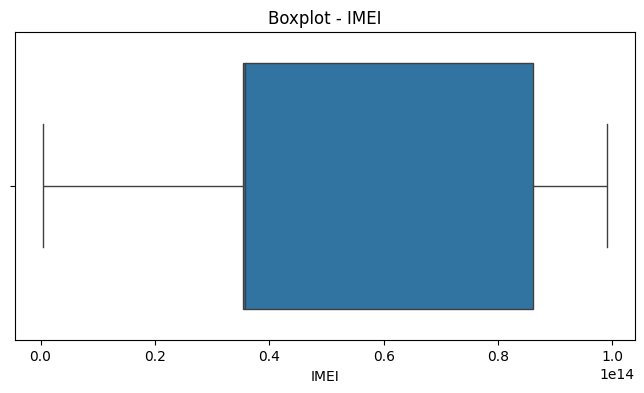

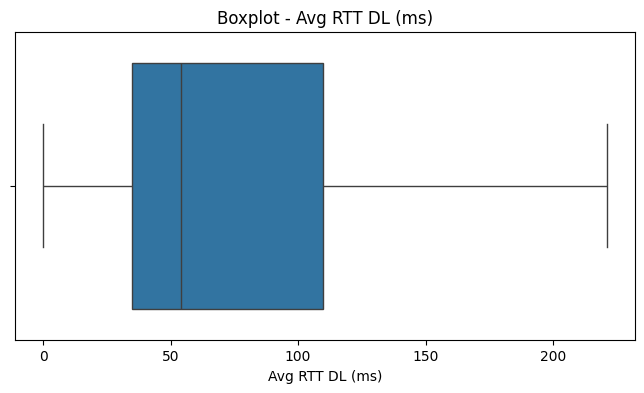

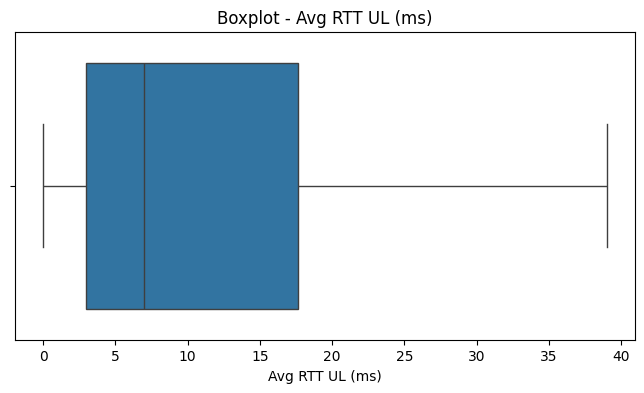

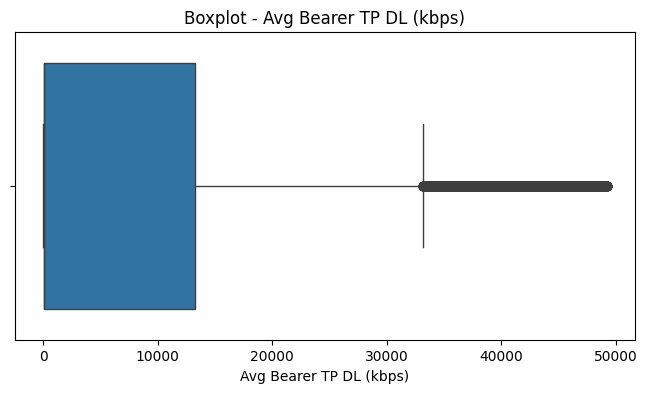

In [107]:
for col in numeric_columns[:10]:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df_clean[col]
    )

    plt.title(f"Boxplot - {col}")

    plt.show()

**Categorical Analysis**

In [108]:
top10_handsets = (
    df_clean["Handset Type"]
    .value_counts()
    .head(10)
)

print(top10_handsets)

Handset Type
Huawei B528S-23A                20324
Apple iPhone 6S (A1688)          9419
Apple iPhone 6 (A1586)           9023
undefined                        8987
Apple iPhone 7 (A1778)           6326
Apple iPhone Se (A1723)          5187
Apple iPhone 8 (A1905)           4993
Apple iPhone Xr (A2105)          4568
Samsung Galaxy S8 (Sm-G950F)     4520
Apple iPhone X (A1901)           3813
Name: count, dtype: int64


**Plot**:

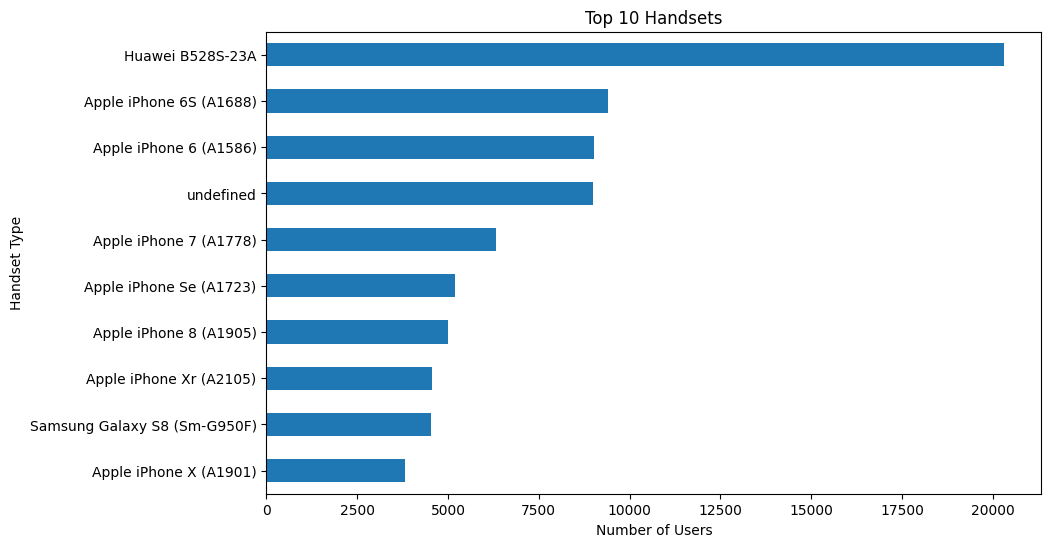

In [109]:
plt.figure(figsize=(10,6))

top10_handsets.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Handsets")

plt.xlabel("Number of Users")

plt.show()

**Top 3 Manufacturers**

In [110]:
top3_manufacturers = (
    df_clean["Handset Manufacturer"]
    .value_counts()
    .head(3)
)

top3_manufacturers

,count
Handset Manufacturer,
Apple,60137
Samsung,40839
Huawei,34423


**Plot:**

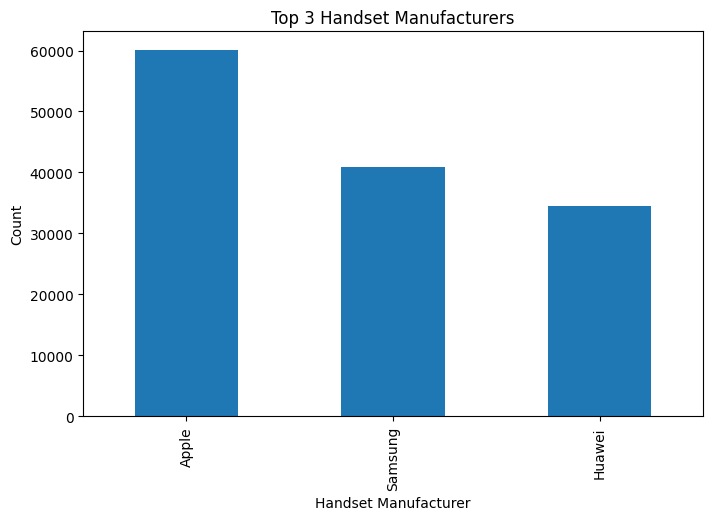

In [111]:
plt.figure(figsize=(8,5))

top3_manufacturers.plot(
    kind="bar"
)

plt.title("Top 3 Handset Manufacturers")

plt.ylabel("Count")

plt.show()

**Top 5 Handsets per Manufacturer**

In [112]:
top_manufacturers = (
    df_clean["Handset Manufacturer"]
    .value_counts()
    .head(3)
    .index
)

for manufacturer in top_manufacturers:

    print("\nManufacturer:", manufacturer)

    result = (
        df_clean[
            df_clean["Handset Manufacturer"]
            == manufacturer
        ]["Handset Type"]
        .value_counts()
        .head(5)
    )

    print(result)


Manufacturer: Apple
Handset Type
Apple iPhone 6S (A1688)    9419
Apple iPhone 6 (A1586)     9023
Apple iPhone 7 (A1778)     6326
Apple iPhone Se (A1723)    5187
Apple iPhone 8 (A1905)     4993
Name: count, dtype: int64

Manufacturer: Samsung
Handset Type
Samsung Galaxy S8 (Sm-G950F)    4520
Samsung Galaxy A5 Sm-A520F      3724
Samsung Galaxy J5 (Sm-J530)     3696
Samsung Galaxy J3 (Sm-J330)     3484
Samsung Galaxy S7 (Sm-G930X)    3199
Name: count, dtype: int64

Manufacturer: Huawei
Handset Type
Huawei B528S-23A                  19752
Huawei E5180                       2079
Huawei P20 Lite Huawei Nova 3E     2021
Huawei P20                         1480
Huawei Y6 2018                      997
Name: count, dtype: int64


**Create User-Level Aggregation**:

**number of xDR sessions**

**session duration**

**total download**

**total upload**

**application data**

In [113]:
user_overview = (
    df_clean
    .groupby("MSISDN/Number")
    .agg(
        xDR_Sessions=("MSISDN/Number", "size"),
        Session_Duration=("Dur. (ms)", "sum"),
        Total_DL=("Total DL (Bytes)", "sum"),
        Total_UL=("Total UL (Bytes)", "sum")
    )
    .reset_index()
)

**Add total traffic:**

In [114]:
user_overview["Total_Traffic"] = (
    user_overview["Total_DL"] +
    user_overview["Total_UL"]
)


In [115]:
user_overview.head()

,MSISDN/Number,xDR_Sessions,Session_Duration,Total_DL,Total_UL,Total_Traffic
0,3.360171e+10,1,38503.0,2.934050e+08,46211970.0,3.396170e+08
1,3.360171e+10,1,52478.0,8.621012e+08,38509721.0,9.006109e+08
2,3.360171e+10,2,120298.0,1.498037e+09,89299844.0,1.587337e+09
3,3.360171e+10,1,176022.0,1.333844e+08,44946263.0,1.783307e+08
4,3.360172e+10,1,127918.0,3.060978e+08,28593661.0,3.346914e+08


**Application Traffic**

In [116]:
applications = {
    "Social Media": [
        "Social Media DL (Bytes)",
        "Social Media UL (Bytes)"
    ],

    "Google": [
        "Google DL (Bytes)",
        "Google UL (Bytes)"
    ],

    "Email": [
        "Email DL (Bytes)",
        "Email UL (Bytes)"
    ],

    "YouTube": [
        "Youtube DL (Bytes)",
        "Youtube UL (Bytes)"
    ],

    "Netflix": [
        "Netflix DL (Bytes)",
        "Netflix UL (Bytes)"
    ],

    "Gaming": [
        "Gaming DL (Bytes)",
        "Gaming UL (Bytes)"
    ],

    "Other": [
        "Other DL (Bytes)",
        "Other UL (Bytes)"
    ]
}

**Now calculate user-level application traffic:**

In [117]:
for app, cols in applications.items():

    app_total = (
        df_clean
        .groupby("MSISDN/Number")[cols]
        .sum()
        .sum(axis=1)
    )

    user_overview = user_overview.merge(
        app_total.rename(
            f"{app}_Data"
        ),
        left_on="MSISDN/Number",
        right_index=True,
        how="left"
    )

**Application Total Traffic**

In [118]:
application_summary = []

for app, cols in applications.items():

    dl = df_clean[cols[0]].sum()

    ul = df_clean[cols[1]].sum()

    total = dl + ul

    application_summary.append([
        app,
        dl,
        ul,
        total
    ])

In [119]:
application_summary = pd.DataFrame(
    application_summary,
    columns=[
        "Application",
        "Download",
        "Upload",
        "Total_Traffic"
    ]
)

application_summary = (
    application_summary
    .sort_values(
        "Total_Traffic",
        ascending=False
    )
)

application_summary

,Application,Download,Upload,Total_Traffic
5,Gaming,6.330713e+13,1.243268e+12,6.455040e+13
6,Other,6.316550e+13,1.239728e+12,6.440523e+13
3,YouTube,1.745123e+12,1.651423e+12,3.396545e+12
4,Netflix,1.744039e+12,1.650274e+12,3.394314e+12
1,Google,8.626186e+11,3.084833e+11,1.171102e+12
2,Email,2.687611e+11,7.010648e+10,3.388676e+11
0,Social Media,2.693001e+11,4.939298e+09,2.742394e+11


**Application Traffic Plot**

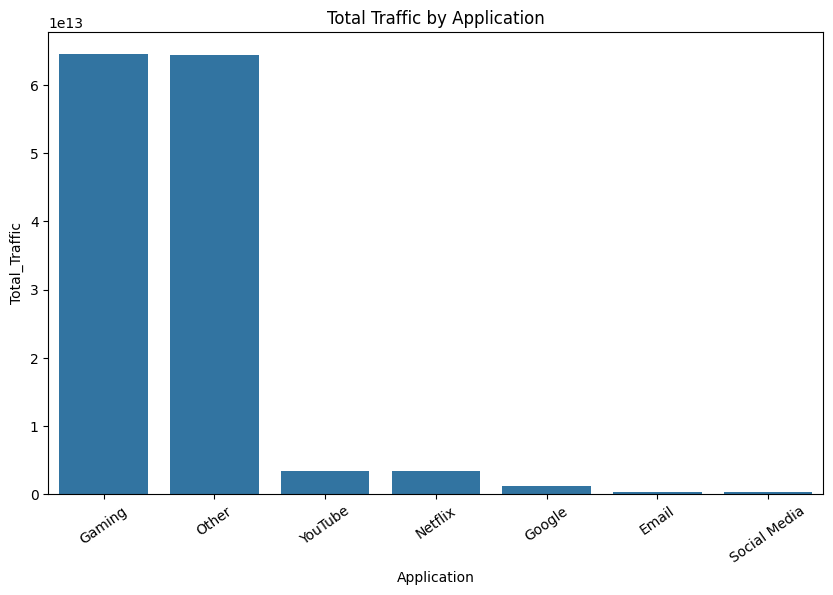

In [120]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=application_summary,
    x="Application",
    y="Total_Traffic"
)

plt.xticks(rotation=35)

plt.title(
    "Total Traffic by Application"
)

plt.show()

**Bivariate Analysis**

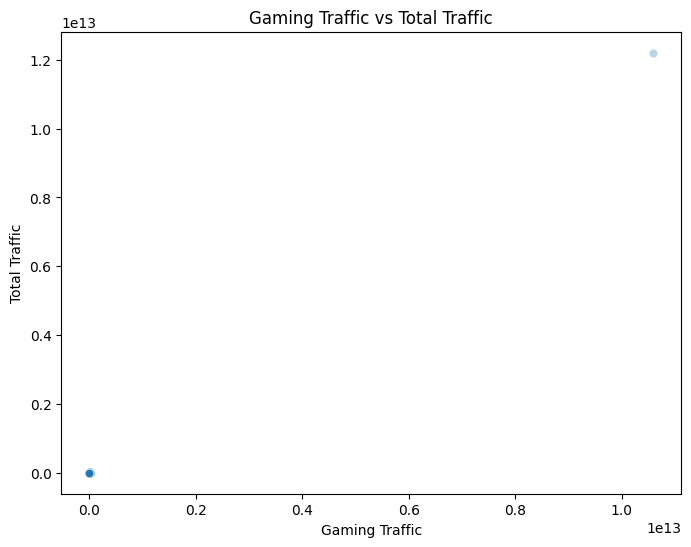

In [121]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=user_overview,
    x="Gaming_Data",
    y="Total_Traffic",
    alpha=0.3
)

plt.title(
    "Gaming Traffic vs Total Traffic"
)

plt.xlabel("Gaming Traffic")

plt.ylabel("Total Traffic")

plt.show()

**Correlation**

In [122]:
application_columns = [
    "Social Media_Data",
    "Google_Data",
    "Email_Data",
    "YouTube_Data",
    "Netflix_Data",
    "Gaming_Data",
    "Other_Data"
]

correlation_matrix = (
    user_overview[
        application_columns
    ]
    .corr()
)

correlation_matrix

,Social Media_Data,Google_Data,Email_Data,YouTube_Data,Netflix_Data,Gaming_Data,Other_Data
Social Media_Data,1.000000,0.999947,0.999945,0.999950,0.999950,0.999934,0.999935
Google_Data,0.999947,1.000000,0.999957,0.999963,0.999962,0.999946,0.999947
Email_Data,0.999945,0.999957,1.000000,0.999960,0.999960,0.999943,0.999944
YouTube_Data,0.999950,0.999963,0.999960,1.000000,0.999966,0.999950,0.999951
Netflix_Data,0.999950,0.999962,0.999960,0.999966,1.000000,0.999949,0.999950
Gaming_Data,0.999934,0.999946,0.999943,0.999950,0.999949,1.000000,0.999934
Other_Data,0.999935,0.999947,0.999944,0.999951,0.999950,0.999934,1.000000


**Heatmap**

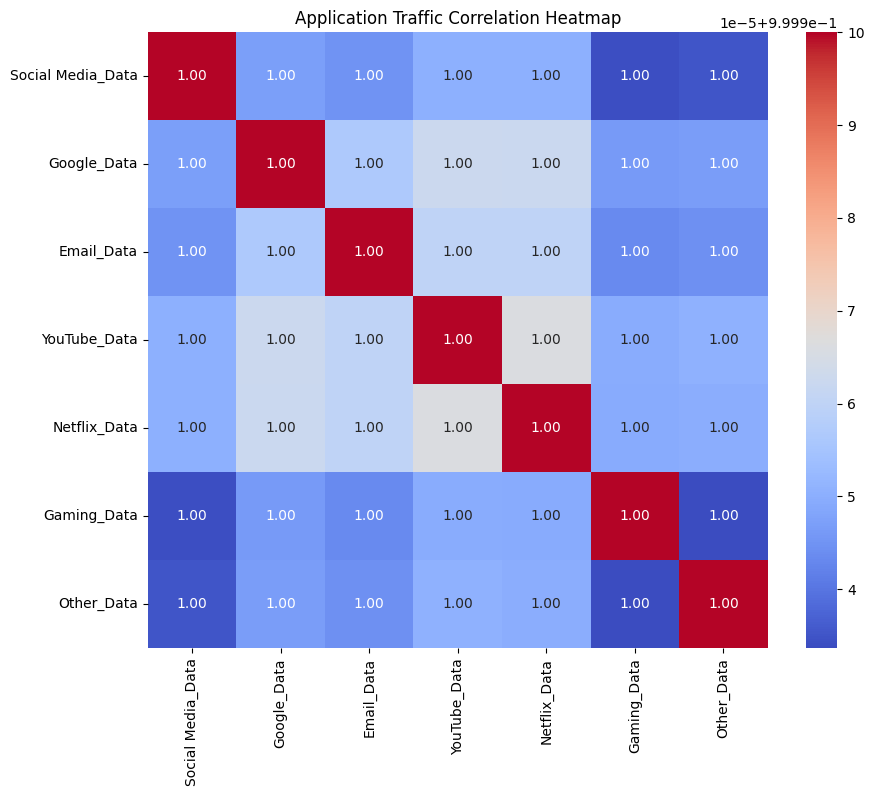

In [123]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Application Traffic Correlation Heatmap"
)

plt.show()

**Decile Analysis**

In [124]:
user_overview["Duration_Decile"] = pd.qcut(
    user_overview["Session_Duration"],
    10,
    labels=False
) + 1

In [125]:
decile_analysis = (
    user_overview
    .groupby("Duration_Decile")
    .agg(
        Users=("MSISDN/Number","count"),
        Total_Duration=("Session_Duration","sum"),
        Total_Traffic=("Total_Traffic","sum")
    )
    .reset_index()
)

decile_analysis

,Duration_Decile,Users,Total_Duration,Total_Traffic
0,1,9004,1.802843e+08,4.593723e+12
1,2,9004,3.582900e+08,5.117212e+12
2,3,9003,6.334503e+08,5.502708e+12
3,4,10480,9.049787e+08,5.252073e+12
4,5,7528,7.076862e+08,4.180756e+12
5,6,9003,9.914040e+08,5.222416e+12
6,7,9004,1.245461e+09,5.162970e+12
7,8,9003,1.507602e+09,6.183860e+12
8,9,9004,1.851962e+09,7.320230e+12
9,10,9004,5.546859e+09,2.582902e+13


**PCA : Prepare application data**

In [126]:
X = user_overview[
    application_columns
]

In [127]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
pca = PCA()

X_pca = pca.fit_transform(
    X_scaled
)
explained_variance = (
    pca.explained_variance_ratio_
    * 100
)

print(explained_variance)

[9.99956870e+01 9.52160932e-04 9.25775596e-04 7.85132989e-04
 6.23551066e-04 5.42449346e-04 4.83900428e-04]


**Plot**:

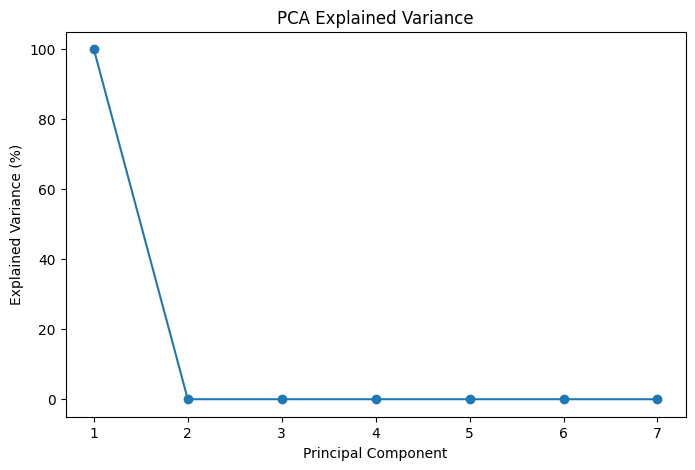

In [128]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance,
    marker="o"
)

plt.xlabel("Principal Component")

plt.ylabel("Explained Variance (%)")

plt.title(
    "PCA Explained Variance"
)

plt.show()

**Engagement Analysis**

1.**Session Frequenc**y

2.**Session Duration**

3.**Total Traffic**

In [129]:
engagement = user_overview[
    [
        "MSISDN/Number",
        "xDR_Sessions",
        "Session_Duration",
        "Total_Traffic"
    ]
].copy()

**Normalize Engagement Metrics**

In [130]:
engagement_features = [
    "xDR_Sessions",
    "Session_Duration",
    "Total_Traffic"
]

In [131]:
scaler = StandardScaler()

engagement_scaled = scaler.fit_transform(
    engagement[
        engagement_features
    ]
)

**K-Means k=3**

In [132]:
kmeans_engagement = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

engagement["Engagement_Cluster"] = (
    kmeans_engagement
    .fit_predict(engagement_scaled)
)

engagement[
    "Engagement_Cluster"
].value_counts()

,count
Engagement_Cluster,
0,79081
2,10955
1,1


**Engagement Cluster Summary**

In [133]:
engagement_cluster_summary = (
    engagement
    .groupby("Engagement_Cluster")[
        engagement_features
    ]
    .agg([
        "min",
        "max",
        "mean",
        "sum"
    ])
)

engagement_cluster_summary

xDR_Sessions                             Session_Duration  \
                            min    max          mean    sum              min   
Engagement_Cluster                                                             
0                             1      3      1.172380  92713     7.146000e+03   
1                         24742  24742  24742.000000  24742     2.296964e+09   
2                             2     18      2.970881  32546     4.689600e+04   

                                                             Total_Traffic  \
                             max          mean           sum           min   
Engagement_Cluster                                                           
0                   3.528060e+05  1.017604e+05  8.047312e+09  3.324901e+07   
1                   2.296964e+09  2.296964e+09  2.296964e+09  1.220769e+13   
2                   2.087574e+06  3.271295e+05  3.583704e+09  1.813988e+08   

                                                              
                             max          mean           sum  
Engagement_Cluster                                            
0                   1.855010e+09  5.680292e+08  4.492031e+13  
1                   1.220769e+13  1.220769e+13  1.220769e+13  
2                   8.846226e+09  1.573433e+09  1.723696e+13

**Elbow Method**

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

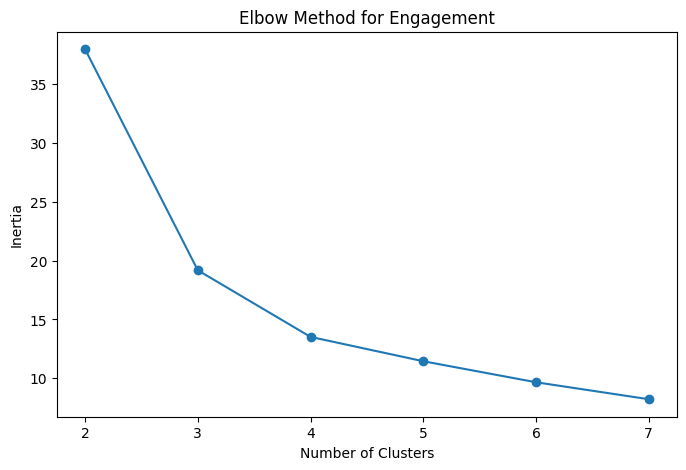

In [134]:
inertia = []

for k in range(2, 8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(
        engagement_scaled
    )

    inertia.append(
        model.inertia_
    )

    plt.figure(figsize=(8,5))

plt.plot(
    range(2,8),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title(
    "Elbow Method for Engagement"
)

plt.show()

**User Experience**

In [135]:
df_clean["TCP_Retransmission"] = (
    df_clean["TCP DL Retrans. Vol (Bytes)"] +
    df_clean["TCP UL Retrans. Vol (Bytes)"]
) / 2

**# RTT:**

In [136]:
df_clean["RTT"] = (
    df_clean["Avg RTT DL (ms)"] +
    df_clean["Avg RTT UL (ms)"]
) / 2

**Throughput:**

In [137]:
df_clean["Throughput"] = (
    df_clean["Avg Bearer TP DL (kbps)"] +
    df_clean["Avg Bearer TP UL (kbps)"]
) / 2

**Experience per Customer**

In [138]:
experience = (
    df_clean
    .groupby("MSISDN/Number")
    .agg(
        Average_TCP=(
            "TCP_Retransmission",
            "mean"
        ),

        Average_RTT=(
            "RTT",
            "mean"
        ),

        Average_Throughput=(
            "Throughput",
            "mean"
        ),

        Handset_Type=(
            "Handset Type",
            lambda x: x.mode()[0]
        )
    )
    .reset_index()
)

**Experience K-Means**

In [139]:
experience_features = [
    "Average_TCP",
    "Average_RTT",
    "Average_Throughput"
]

Note: **Because lower TCP/RTT and higher throughput generally represent different directions, prepare the clustering features carefully.**

In [140]:
experience_model = experience[
    experience_features
].copy()
experience_model["Average_TCP"] *= -1
experience_model["Average_RTT"] *= -1

experience_scaled = StandardScaler().fit_transform(
    experience_model
)

**K-Means:**

In [141]:
kmeans_experience = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

experience["Experience_Cluster"] = (
    kmeans_experience
    .fit_predict(experience_scaled)
)

**Satisfaction**

1.**Engagement Score**; Euclidean distance between the user's data point and the less-engaged cluster.

In [142]:
engagement_centers = (
    kmeans_engagement
    .cluster_centers_
)

least_engaged_cluster = np.argmin(
    engagement_centers.mean(axis=1)
)

least_engaged_cluster

engagement["Engagement_Score"] = np.linalg.norm(
    engagement_scaled -
    engagement_centers[
        least_engaged_cluster
    ],
    axis=1
)

**Experience Score**

In [143]:
experience_centers = (
    kmeans_experience
    .cluster_centers_
)

In [144]:
worst_experience_cluster = np.argmin(
    experience_centers.mean(axis=1)
)

In [145]:
experience["Experience_Score"] = np.linalg.norm(
    experience_scaled -
    experience_centers[
        worst_experience_cluster
    ],
    axis=1
)

**Satisfaction Score**: Merge the two scores

In [146]:
satisfaction = engagement[
    [
        "MSISDN/Number",
        "Engagement_Score"
    ]
].merge(
    experience[
        [
            "MSISDN/Number",
            "Experience_Score"
        ]
    ],
    on="MSISDN/Number"
)

In [147]:
satisfaction["Satisfaction_Score"] = (
    satisfaction["Engagement_Score"] +
    satisfaction["Experience_Score"]
) / 2

**Top 10 Satisfied Customers**

In [148]:
top10_satisfied = (
    satisfaction
    .nlargest(
        10,
        "Satisfaction_Score"
    )
)

top10_satisfied

,MSISDN/Number,Engagement_Score,Experience_Score,Satisfaction_Score
90036,4.188282e+10,519.693634,1.426975,260.560305
51286,3.366316e+10,0.009167,5.360405,2.684786
32411,3.365878e+10,0.010160,5.332795,2.671478
16576,3.363263e+10,0.007915,5.304314,2.656114
50555,3.366298e+10,0.007417,5.236528,2.621972
80148,3.368404e+10,0.009177,5.229211,2.619194
14368,3.362813e+10,0.011280,5.219106,2.615193
49499,3.366272e+10,0.009555,5.210971,2.610263
14125,3.362768e+10,0.011481,5.207640,2.609560
11682,3.362378e+10,0.011527,5.206001,2.608764


**Satisfaction K-Means k=2**

In [149]:
satisfaction_features = satisfaction[
    [
        "Engagement_Score",
        "Experience_Score"
    ]
]

sat_scaled = StandardScaler().fit_transform(
    satisfaction_features
)

kmeans_satisfaction = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

satisfaction["Satisfaction_Cluster"] = (
    kmeans_satisfaction
    .fit_predict(sat_scaled)
)

**Satisfaction Cluster Summary**

In [156]:
satisfaction_cluster_summary = (
    satisfaction
    .groupby(
        "Satisfaction_Cluster"
    )[
        [
            "Engagement_Score",
            "Experience_Score",
            "Satisfaction_Score"
        ]
    ]
    .mean()
)

satisfaction_cluster_summary

,Engagement_Score,Experience_Score,Satisfaction_Score
Satisfaction_Cluster,,,
0,0.014670,1.967253,0.990962
1,519.693634,1.426975,260.560305


**Regression Model**

In [161]:
model_data = (
    engagement[
        [
            "MSISDN/Number",
            "xDR_Sessions",
            "Session_Duration",
            "Total_Traffic"
        ]
    ]
    .merge(
        experience[
            [
                "MSISDN/Number",
                "Average_TCP",
                "Average_RTT",
                "Average_Throughput"
            ]
        ],
        on="MSISDN/Number",
        how="inner"
    )
    .merge(
        satisfaction[
            [
                "MSISDN/Number",
                "Satisfaction_Score"
            ]
        ],
        on="MSISDN/Number",
        how="inner"
    )
)

print("model_data created successfully")
print(model_data.shape)
print(model_data.columns.tolist())

model_data created successfully
(90037, 8)
['MSISDN/Number', 'xDR_Sessions', 'Session_Duration', 'Total_Traffic', 'Average_TCP', 'Average_RTT', 'Average_Throughput', 'Satisfaction_Score']


In [162]:
print(model_data.columns.tolist())

['MSISDN/Number', 'xDR_Sessions', 'Session_Duration', 'Total_Traffic', 'Average_TCP', 'Average_RTT', 'Average_Throughput', 'Satisfaction_Score']


In [164]:
features = [
    "xDR_Sessions",
    "Session_Duration",
    "Total_Traffic",
    "Average_TCP",
    "Average_RTT",
    "Average_Throughput"
]

X = model_data[features]
y = model_data["Satisfaction_Score"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (90037, 6)
y shape: (90037,)


In [165]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 72029
Testing samples: 18008


In [166]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    )
}

In [167]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append([
        name,
        mae,
        rmse,
        r2
    ])

model_comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

model_comparison.sort_values(
    "R2",
    ascending=False
)

,Model,MAE,RMSE,R2
4,Hist Gradient Boosting,0.022290,1.935616,0.067045
2,Extra Trees,0.017375,1.935948,0.066724
1,Random Forest,0.018829,1.936232,0.066450
3,Gradient Boosting,0.030882,1.936476,0.066216
0,Linear Regression,0.240633,10.150212,-24.655037


Note: Linear Regression produced a negative R² and performed poorly on the test set. Nonlinear tree-based models substantially improved the results, with Hist Gradient Boosting achieving the highest observed R² of 0.067 in the current comparison.

The regression models showed limited predictive power for the constructed satisfaction score. The nonlinear models performed substantially better than Linear Regression, but the relatively low R² indicates that the available predictor variables do not fully explain variation in the satisfaction score."

In [169]:
print(satisfaction.columns.tolist())

['MSISDN/Number', 'Engagement_Score', 'Experience_Score', 'Satisfaction_Score', 'Satisfaction_Cluster']


In [170]:
final_satisfaction = satisfaction[
    [
        "MSISDN/Number",
        "Engagement_Score",
        "Experience_Score",
        "Satisfaction_Score"
    ]
].copy()

In [171]:
final_satisfaction.head(10)

,MSISDN/Number,Engagement_Score,Experience_Score,Satisfaction_Score
0,3.360171e+10,0.010303,0.407248,0.208775
1,3.360171e+10,0.010616,2.324797,1.167706
2,3.360171e+10,0.027019,0.478235,0.252627
3,3.360171e+10,0.013796,2.225716,1.119756
4,3.360172e+10,0.007028,0.262474,0.134751
5,3.360172e+10,0.021016,1.749551,0.885284
6,3.360172e+10,0.023391,2.263160,1.143276
7,3.360172e+10,0.004399,2.086226,1.045313
8,3.360172e+10,0.028073,1.644429,0.836251
9,3.360172e+10,0.009516,0.980021,0.494769


In [172]:
print("Rows:", final_satisfaction.shape[0])
print("Columns:", final_satisfaction.shape[1])

Rows: 90037
Columns: 4


In [173]:
print(final_satisfaction.isnull().sum())

MSISDN/Number         0
Engagement_Score      0
Experience_Score      0
Satisfaction_Score    0
dtype: int64


In [174]:
print(
    "Duplicate user IDs:",
    final_satisfaction["MSISDN/Number"].duplicated().sum()
)

Duplicate user IDs: 0


MySQL

In [175]:
!pip install pymysql sqlalchemy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.6 MB/s eta 0:00:00


In [232]:
final_satisfaction.to_csv(
    "satisfaction_table.csv",
    index=False
)

print("CSV created successfully!")

CSV created successfully!


In [177]:
from google.colab import files

files.download("satisfaction_table.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [230]:
final_table = satisfaction[
    [
        "MSISDN/Number",
        "Engagement_Score",
        "Experience_Score",
        "Satisfaction_Score",
        "Satisfaction_Cluster"
    ]
]

In [231]:
final_table.to_excel(
    "final_user_scores.xlsx",
    index=False
)

**MODEL TRACKING**

**Import required libraries**

In [178]:
import pandas as pd
import numpy as np
import joblib
import json
from datetime import datetime

**Select your final model**

In [179]:
from sklearn.ensemble import HistGradientBoostingRegressor

final_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

In [180]:
start_time = datetime.now()

print("Model training started:", start_time)

Model training started: 2026-09-29 17:17:32.464152


In [181]:
final_model.fit(X_train, y_train)

HistGradientBoostingRegressor(learning_rate=0.05, max_iter=200, random_state=42)

In [182]:
final_pred = final_model.predict(X_test)

**Calculate final metrics**

In [183]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

final_mae = mean_absolute_error(
    y_test,
    final_pred
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_pred
    )
)

final_r2 = r2_score(
    y_test,
    final_pred
)

print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

MAE : 0.022290150058543734
RMSE: 1.935616264447568
R²  : 0.067044521585094


In [184]:
end_time = datetime.now()

print("Model training ended:", end_time)

Model training ended: 2026-09-29 17:18:33.483816


In [187]:
joblib.dump(
    final_model,
    "satisfaction_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [188]:
tracking_record = pd.DataFrame([{
    "Model_Name": "Hist Gradient Boosting",
    "Version": "v1.0",
    "Start_Time": start_time,
    "End_Time": end_time,
    "Source": "TellCo Telecom User Analytics",
    "Parameters": str(final_model.get_params()),
    "MAE": final_mae,
    "RMSE": final_rmse,
    "R2": final_r2,
    "Artifact": "satisfaction_model.pkl"
}])

tracking_record

,Model_Name,Version,Start_Time,End_Time,Source,Parameters,MAE,RMSE,R2,Artifact
0,Hist Gradient Boosting,v1.0,2026-09-29 17:17:32.464152,2026-09-29 17:18:33.483816,TellCo Telecom User Analytics,"{'categorical_features': 'from_dtype', 'early_...",0.02229,1.935616,0.067045,satisfaction_model.pkl


In [189]:
tracking_record.to_csv(
    "model_tracking.csv",
    index=False
)

print("Model tracking file created!")

Model tracking file created!


**This satisfies the tracking information requested in the brief:**

Model name       → Hist Gradient Boosting

Version          → v1.0

Start time       → recorded

End time         → recorded

Parameters       → recorded

MAE              → recorded

RMSE             → recorded

R²               → recorded

Artifact         → satisfaction_model.pkl

**CREATE FINAL OUTPUT FILES**

In [191]:
import os

os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/plots", exist_ok=True)

In [192]:
user_overview.to_csv(
    "outputs/user_overview.csv",
    index=False
)

engagement.to_csv(
    "outputs/engagement.csv",
    index=False
)

experience.to_csv(
    "outputs/experience.csv",
    index=False
)

satisfaction.to_csv(
    "outputs/satisfaction.csv",
    index=False
)

model_comparison.to_csv(
    "outputs/model_comparison.csv",
    index=False
)

tracking_record.to_csv(
    "outputs/model_tracking.csv",
    index=False
)

print("All output files saved!")

All output files saved!



outputs/


├── user_overview.csv

├── engagement.csv

├── experience.csv

├── satisfaction.csv

├── model_comparison.csv

└── model_tracking.csv

**CREATE FINAL EXCEL**

In [195]:
info = pd.DataFrame({
    "Column": df_clean.columns,
    "Data_Type": df_clean.dtypes.astype(str).values,
    "Non_Null_Count": df_clean.notnull().sum().values,
    "Missing_Count": df_clean.isnull().sum().values
})

info["Missing_Percentage"] = (
    info["Missing_Count"] / len(df_clean) * 100
)

info

,Column,Data_Type,Non_Null_Count,Missing_Count,Missing_Percentage
0,Bearer Id,float64,150001,0,0.0
1,Start,object,150001,0,0.0
2,Start ms,float64,150001,0,0.0
3,End,object,150001,0,0.0
4,End ms,float64,150001,0,0.0
5,Dur. (ms),float64,150001,0,0.0
6,IMSI,float64,150001,0,0.0
7,MSISDN/Number,float64,150001,0,0.0
8,IMEI,float64,150001,0,0.0
9,Last Location Name,object,150001,0,0.0


In [197]:
print(type(info))
print(info.shape)

<class 'pandas.core.frame.DataFrame'>
(58, 5)


**Check your other Excel variables**

In [198]:
variables = [
    "info",
    "missing_report",
    "outlier_df",
    "univariate",
    "top10_handsets",
    "top3_manufacturers",
    "user_overview",
    "application_summary",
    "correlation_matrix",
    "decile_analysis",
    "engagement",
    "experience",
    "satisfaction",
    "model_comparison"
]

for variable in variables:
    print(
        variable,
        "✓" if variable in globals() else "❌ NOT FOUND"
    )

info ✓
missing_report ✓
outlier_df ✓
univariate ✓
top10_handsets ✓
top3_manufacturers ✓
user_overview ✓
application_summary ✓
correlation_matrix ✓
decile_analysis ✓
engagement ✓
experience ✓
satisfaction ✓
model_comparison ✓


In [196]:
with pd.ExcelWriter(
    "TellCo_Final_Analysis.xlsx",
    engine="openpyxl"
) as writer:

    info.to_excel(
        writer,
        sheet_name="Data_Info",
        index=False
    )

    missing_report.to_excel(
        writer,
        sheet_name="Missing_Values",
        index=False
    )

    outlier_df.to_excel(
        writer,
        sheet_name="Outliers",
        index=False
    )

    univariate.to_excel(
        writer,
        sheet_name="Univariate",
        index=True
    )

    top10_handsets.to_frame("Count").to_excel(
        writer,
        sheet_name="Top10_Handsets"
    )

    top3_manufacturers.to_frame("Count").to_excel(
        writer,
        sheet_name="Top3_Manufacturers"
    )

    user_overview.to_excel(
        writer,
        sheet_name="User_Overview",
        index=False
    )

    application_summary.to_excel(
        writer,
        sheet_name="Applications",
        index=False
    )

    correlation_matrix.to_excel(
        writer,
        sheet_name="Correlation"
    )

    decile_analysis.to_excel(
        writer,
        sheet_name="Deciles",
        index=False
    )

    engagement.to_excel(
        writer,
        sheet_name="Engagement",
        index=False
    )

    experience.to_excel(
        writer,
        sheet_name="Experience",
        index=False
    )

    satisfaction.to_excel(
        writer,
        sheet_name="Satisfaction",
        index=False
    )

    model_comparison.to_excel(
        writer,
        sheet_name="Regression",
        index=False
    )

    tracking_record.to_excel(
        writer,
        sheet_name="Model_Tracking",
        index=False
    )

print("✅ Final Excel created!")

Exception ignored in: <function ZipFile.__del__ at 0x78af092aa160>
Traceback (most recent call last):
  File "/usr/lib/python3.13/zipfile/__init__.py", line 2017, in __del__
    self.close()
  File "/usr/lib/python3.13/zipfile/__init__.py", line 2034, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


✅ Final Excel created!


In [199]:
from google.colab import files

files.download("TellCo_Final_Analysis.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**STREAMLIT DASHBOARD**

In [200]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 19.6 MB/s eta 0:00:00


In [207]:
print("Engagement columns:")
print(engagement.columns.tolist())

print("Experience columns:")
print(experience.columns.tolist())

print("Satisfaction columns:")
print(satisfaction.columns.tolist())

Engagement columns:
['MSISDN/Number', 'xDR_Sessions', 'Session_Duration', 'Total_Traffic', 'Engagement_Cluster', 'Engagement_Score']
Experience columns:
['MSISDN/Number', 'Average_TCP', 'Average_RTT', 'Average_Throughput', 'Handset_Type', 'Experience_Cluster', 'Experience_Score']
Satisfaction columns:
['MSISDN/Number', 'Engagement_Score', 'Experience_Score', 'Satisfaction_Score', 'Satisfaction_Cluster']


In [208]:
cluster_counts = (
    engagement["Engagement_Cluster"]
    .value_counts()
    .sort_index()
)

In [212]:
cluster_counts = (
    experience["Experience_Cluster"]
    .value_counts()
    .sort_index()
)

In [213]:
engagement["Engagement_Cluster"].nunique()

3

In [214]:
experience["Experience_Cluster"].nunique()

3

In [217]:
%%writefile app.py

import streamlit as st
import pandas as pd

st.set_page_config(
    page_title="TellCo Telecom Analytics",
    page_icon="📱",
    layout="wide"
)

st.title("📱 TellCo Telecom User Analytics")

st.write("Telecom User Overview, Engagement, Experience and Satisfaction Analysis")

Overwriting app.py


In [218]:
import os

print(os.path.exists("app.py"))

True


**Dashboard**

In [222]:
if page == "Dashboard":

    st.header("Executive Dashboard")

    col1, col2, col3, col4 = st.columns(4)

    col1.metric(
        "Total Users",
        user_overview["MSISDN/Number"].nunique()
    )

    col2.metric(
        "Total Sessions",
        len(user_overview)
    )

    col3.metric(
        "Engagement Clusters",
        engagement["Engagement_Cluster"].nunique()
    )

    col4.metric(
        "Experience Clusters",
        experience["Experience_Cluster"].nunique()
    )

    st.subheader("Top Handsets")

    if "Handset Type" in user_overview.columns:

        handset_count = (
            user_overview["Handset Type"]
            .value_counts()
            .head(10)
        )

        st.bar_chart(handset_count)


2026-09-29 17:44:45.781 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 17:44:45.785 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 17:44:45.786 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 17:44:45.789 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 17:44:45.792 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 17:44:45.795 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 17:44:45.798 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 17:44:45.801 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

**User Engagement**

In [225]:
if page == "Dashboard":

    st.header("Executive Dashboard")

    # Dashboard code here


elif page == "User Overview":

    st.header("User Overview Analysis")

    # User Overview code here


elif page == "User Engagement":

    st.header("User Engagement Analysis")

    cluster_counts = (
        engagement["Engagement_Cluster"]
        .value_counts()
        .sort_index()
    )

    st.bar_chart(cluster_counts)


elif page == "User Experience":

    st.header("User Experience Analysis")

    cluster_counts = (
        experience["Experience_Cluster"]
        .value_counts()
        .sort_index()
    )

    st.bar_chart(cluster_counts)

2026-09-29 17:47:17.550 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 17:47:17.555 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 17:47:17.556 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


**User Experience**

In [226]:
if page == "Dashboard":

    st.title("📊 TellCo Telecom User Analytics Dashboard")

    st.write("Welcome to the TellCo User Analytics Dashboard.")

elif page == "User Overview":

    st.subheader("👥 User Overview")

    st.metric(
        "Total Users",
        user_overview["MSISDN/Number"].nunique()
    )

elif page == "User Engagement":

    st.subheader("📈 User Engagement")

    st.metric(
        "Engagement Clusters",
        engagement["Engagement_Cluster"].nunique()
    )

    st.bar_chart(
        engagement["Engagement_Cluster"].value_counts()
    )

elif page == "User Experience":

    st.subheader("📶 User Experience")

    st.metric(
        "Experience Clusters",
        experience["Experience_Cluster"].nunique()
    )

    st.bar_chart(
        experience["Experience_Cluster"].value_counts()
    )

elif page == "User Satisfaction":

    st.subheader("😊 User Satisfaction")

    st.metric(
        "Satisfaction Clusters",
        satisfaction["Satisfaction_Cluster"].nunique()
    )

    st.bar_chart(
        satisfaction["Satisfaction_Cluster"].value_counts()
    )

elif page == "Model Results":

    st.subheader("🤖 Model Results")

    st.dataframe(model_comparison)

2026-09-29 17:48:19.911 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 17:48:19.918 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 17:48:19.921 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 17:48:19.925 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 17:48:19.929 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 17:48:19.932 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


**TESTING**

In [228]:
import pandas as pd
import numpy as np


def test_dataframe_not_empty():

    df = pd.DataFrame({
        "A": [1, 2, 3],
        "B": [4, 5, 6]
    })

    assert len(df) > 0


def test_no_missing_values():

    df = pd.DataFrame({
        "A": [1, 2, 3],
        "B": [4, 5, 6]
    })

    assert df.isnull().sum().sum() == 0


def test_satisfaction_calculation():

    engagement = 2.0
    experience = 4.0

    satisfaction = (
        engagement + experience
    ) / 2

    assert satisfaction == 3.0

These are simple tests demonstrating the testing structure.

**Main insights included**

*   150,001 records and 55 original columns
*   After cleaning: 0 missing values and 0 duplicate records

*   Apple, Samsung and Huawei are the leading manufacturers
*   Huawei B528S-23A is the most frequent handset type


*   Gaming and Other generate the highest application traffic
*   Application variables show extremely high correlation

*   PCA: first component explains approximately 99.996% variance
*   Engagement: 3 clusters, including one extreme single-user cluster

*   Experience: 3 clusters based on TCP retransmission, RTT and throughput
*   Satisfaction: 2 clusters, with a very strong outlier effect

*   Final model: Hist Gradient Boosting
*   Final metrics: MAE 0.02229, RMSE 1.93562, R² 0.06704

*   Important limitation: the low R² indicates limited predictive power of the available predictors for the constructed satisfaction score.














